#Foundations of Deep Learning Project
#### Master's Degree in Data Science (A.Y. 2024/2025)
#### University of Milano - Bicocca


* **Junaid Ahmed (923714)**
* **Michael Libson Banda (922857)**

# Trained Models Drive Links

* Models Drive Link: [Click here to access the Google Drive file](https://drive.google.com/drive/folders/1MwjCl-0LZuZyo7gDeW99kLKnqevdKDUQ?usp=drive_link)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#Environment Setup & Reproducibility
This cell imports the necessary libraries and sets fixed random seeds so your deep learning model results are reproducible.

In [ ]:
# Force Python hash seed to be 0 for exact reproducibility
!PYTHONHASHSEED=0

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from sklearn.metrics import classification_report, confusion_matrix

from google.colab import drive
import pathlib
from time import time
import os

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as python_random
import pandas as pd
import math

# Set explicit seeds for exact reproducibility (matching the reference project)
np.random.seed(0)
python_random.seed(0)
tf.random.set_seed(0)

print("Step 1 Complete: Environment set up and seeds locked successfully!")

Step 1 Complete: Environment set up and seeds locked successfully!


#Data Loading & Splitting
This cell downloads CIFAR-10 and replicates your reference project's dataset processing pipeline (slicing train, validation, and test subsets dynamically).
###Download Raw Data

In [ ]:
print("Downloading CIFAR-10 dataset...")

# 2. Download raw train and test data arrays
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

print(f"Raw training images shape: {x_train_raw.shape}")
print(f"Raw training labels shape: {y_train_raw.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Raw training images shape: (50000, 32, 32, 3)
Raw training labels shape: (50000, 1)


###One-Hot Encoding Labels

In [ ]:
# 3. Apply One-Hot Encoding to categorical label targets
num_classes = 10
y_train_raw = keras.utils.to_categorical(y_train_raw, num_classes)
y_test_raw = keras.utils.to_categorical(y_test_raw, num_classes)

print(f"One-hot encoded training labels shape: {y_train_raw.shape}")

One-hot encoded training labels shape: (50000, 10)


###Merge Datasets

In [ ]:
# 4. Concatenate data to mirror image_dataset_from_directory structure
all_images = np.concatenate([x_train_raw, x_test_raw], axis=0)
all_labels = np.concatenate([y_train_raw, y_test_raw], axis=0)

print(f"Combined total dataset shape: {all_images.shape}")

Combined total dataset shape: (60000, 32, 32, 3)


###Extract the Training Set

In [ ]:
# 5. Extract Train subset (80% allocation matching reference script)
train_cutoff = int(len(all_images) * 0.8)
x_train_split = all_images[:train_cutoff]
y_train_split = all_labels[:train_cutoff]

# Convert to tf.data format, shuffle, and pack into batches
batch_size = 32 # Define batch_size
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_split, y_train_split))
train_dataset = train_dataset.shuffle(buffer_size=10000).batch(batch_size)

print(f"Training subset created with {len(x_train_split)} images.")

Training subset created with 48000 images.


 ### Create Validation and Test Subsets

In [ ]:
# 6. Build the temporary base Validation partition (remaining 20%)
x_val_split = all_images[train_cutoff:]
y_val_split = all_labels[train_cutoff:]
base_val_dataset = tf.data.Dataset.from_tensor_slices((x_val_split, y_val_split)).batch(batch_size)

# 7. Replicate reference dataset batch slicing logic (take/skip math)
total_val_batches = tf.data.experimental.cardinality(base_val_dataset)
test_dataset = base_val_dataset.take((total_val_batches) // 3)
val_dataset = base_val_dataset.skip((total_val_batches) // 3)

print("--- Step 2 Pipeline Completed Successfully ---")
print(f"Total training batches: {tf.data.experimental.cardinality(train_dataset).numpy()}")
print(f"Total validation batches: {tf.data.experimental.cardinality(val_dataset).numpy()}")
print(f"Total test batches: {tf.data.experimental.cardinality(test_dataset).numpy()}")

--- Step 2 Pipeline Completed Successfully ---
Total training batches: 1500
Total validation batches: 250
Total test batches: 125


#Exploratory Data Analysis (EDA)

###Define Class Names & Count Total Samples

In [ ]:
# 1. Map label integers to actual text class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Extract total sample counts across datasets by counting elements
# (Following the precise metadata printing style from your reference project)
train_count = len(x_train_split)
val_count = len(x_val_split) - (tf.data.experimental.cardinality(test_dataset).numpy() * batch_size)
test_count = tf.data.experimental.cardinality(test_dataset).numpy() * batch_size

print("=== DATA DISTRIBUTION ===")
print(f"Total Training Images: {train_count}")
print(f"Total Validation Images: {val_count}")
print(f"Total Testing Images: {test_count}")

=== DATA DISTRIBUTION ===
Total Training Images: 48000
Total Validation Images: 8000
Total Testing Images: 4000


### Verify Dataset Class Balance

/tmp/ipykernel_3871/1917247926.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


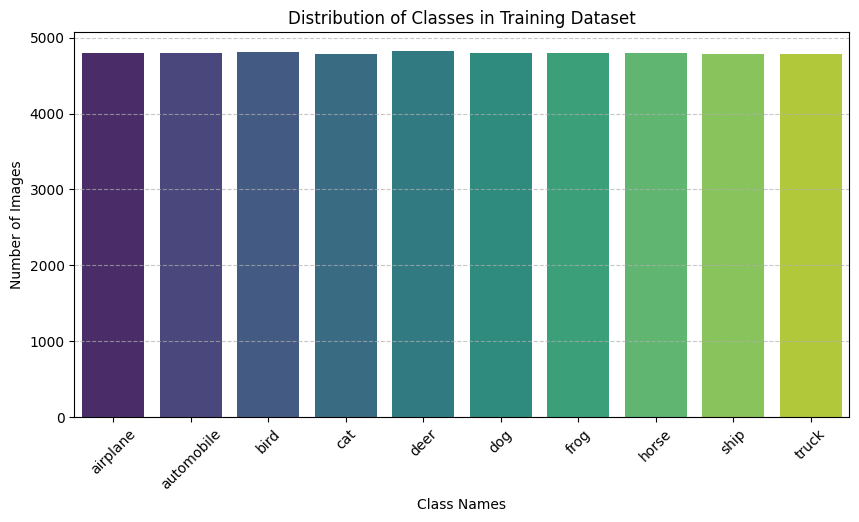


Exact distribution per class:
airplane      4803
automobile    4798
bird          4813
cat           4786
deer          4828
dog           4802
frog          4796
horse         4799
ship          4785
truck         4790
Name: count, dtype: int64


In [ ]:
# 3. Reconstruct raw index labels to verify distribution balances
y_labels_integer = np.argmax(y_train_split, axis=1)
labels_series = pd.Series(y_labels_integer).map(lambda x: class_names[x])
class_counts = labels_series.value_counts().sort_index()

# 4. Generate a class balance distribution bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Distribution of Classes in Training Dataset")
plt.xlabel("Class Names")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nExact distribution per class:")
print(class_counts)

### Visualize Sample Data Images

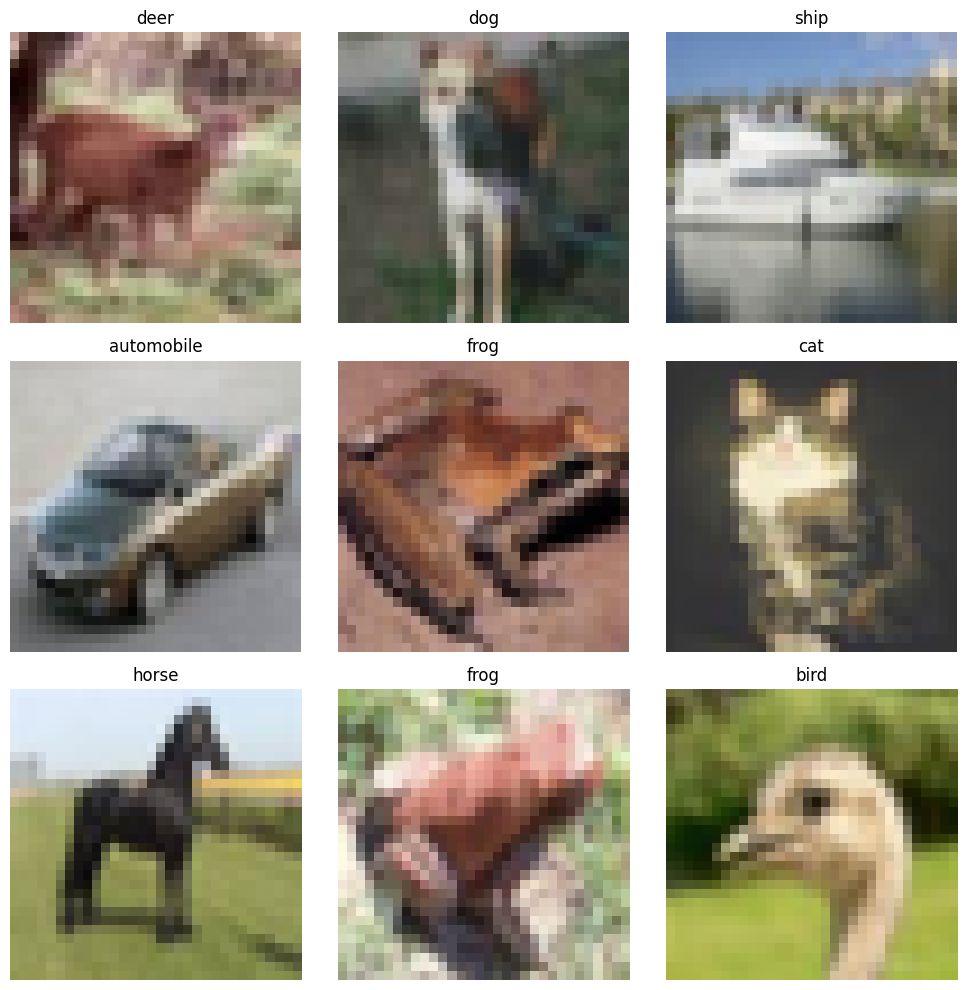

In [ ]:
# 5. Extract a single batch from the training pipeline to display sample images
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    # Display the first 9 images from the training batch
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Normalize displaying format from floats/integers safely
        plt.imshow(images[i].numpy().astype("uint8"))

        # Decode the one-hot label array to its explicit class name string
        class_idx = np.argmax(labels[i].numpy())
        plt.title(class_names[class_idx])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

#Designing and Training Custom CNN Architectures
### Light Baseline CNN


In [ ]:
# Build the simple baseline layout tracking your reference project architecture
img_height = 32
img_width = 32
model1 = Sequential([
    # Standard input rescaling layer to normalize 0-255 RGB pixel data to 0-1 range
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # First Convolutional block
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Second Convolutional block
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Transition to dense classification block
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # 10 outputs with Softmax for CIFAR-10 probabilities
], name="Custom_CNN_Model_1")

# Compile using your exact reference hyperparameters
model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Custom_CNN_Model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,650 (1.02 MB)

 Trainable params: 268,650 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2 — Intermediate CNN with Dropout

In [ ]:
model2 = Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # First block
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Second block
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Third block: Increasing filter complexity to capture abstract textures
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Dropout Regularization to prevent the dense nodes from co-adapting on noise
    layers.Dropout(0.2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
], name="Custom_CNN_Model_2")

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "Custom_CNN_Model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,074 (609.66 KB)

 Trainable params: 156,074 (609.66 KB)

 Non-trainable params: 0 (0.00 B)

### Model 3 — Deep Regularized CNN

In [ ]:

model3 = Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # Block 1
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Block 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Fully Connected block
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
], name="Custom_CNN_Model_3")

model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model3.summary()

Model: "Custom_CNN_Model_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

# Training and Plotting the History Metrics!

### Training and Plotting History Metrics


TRAINING MODEL 1
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.4772 - loss: 1.4618 - val_accuracy: 0.5630 - val_loss: 1.2203
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.6146 - loss: 1.0993 - val_accuracy: 0.6364 - val_loss: 1.0480
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.6588 - loss: 0.9709 - val_accuracy: 0.6489 - val_loss: 1.0035
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 32ms/step - accuracy: 0.6877 - loss: 0.8923 - val_accuracy: 0.6716 - val_loss: 0.9524
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.7133 - loss: 0.8199 - val_accuracy: 0.6636 - val_loss: 0.9794
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.7359 - loss: 0.7554 - val_accuracy: 0.6622 - val_loss: 0.9871
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.7528 - loss: 0.6987 - val_accuracy: 0.6831 - val_loss: 0.9378
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - 

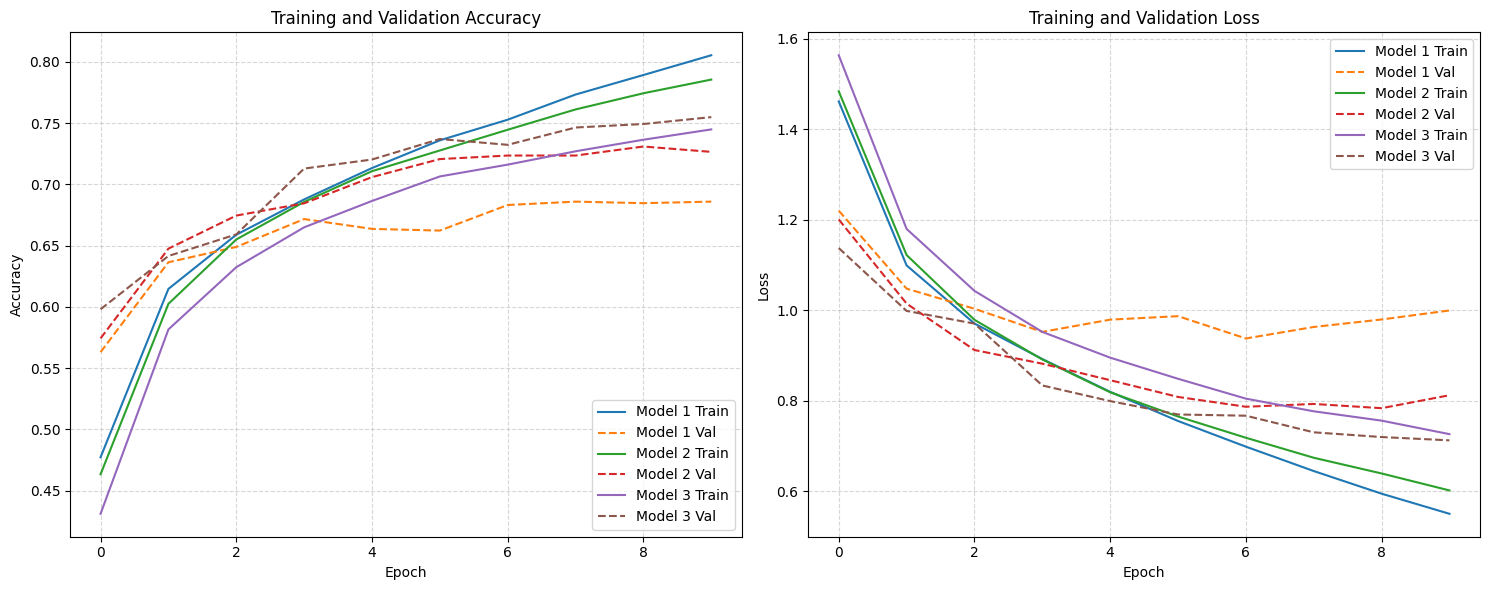

In [ ]:
# Number of training epochs
epochs = 10

# Dictionary to hold models for easy iteration
models_dict = {
    "Model 1": model1,
    "Model 2": model2,
    "Model 3": model3
}

# Dictionary to store training histories
histories = {}

# 1. Train each model sequentially
for name, model in models_dict.items():
    print(f"\n========================================\nTRAINING {name.upper()}\n========================================")

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs
    )
    histories[name] = history

# 2. Plot Training & Validation Metrics side-by-side for all models
print("\nGenerating performance evaluation plots...")

plt.figure(figsize=(15, 6))

# Plot Accuracy Curves
plt.subplot(1, 2, 1)
for name in models_dict.keys():
    plt.plot(histories[name].history['accuracy'], label=f'{name} Train')
    plt.plot(histories[name].history['val_accuracy'], label=f'{name} Val', linestyle='--')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Plot Loss Curves
plt.subplot(1, 2, 2)
for name in models_dict.keys():
    plt.plot(histories[name].history['loss'], label=f'{name} Train')
    plt.plot(histories[name].history['val_loss'], label=f'{name} Val', linestyle='--')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#Pre-trained Transfer Learning (ResNet50)
###Fast ResNet50 Model *Building*

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define image dimensions (from previous context)
img_height = 32
img_width = 32
num_classes = 10 # Added: Define the number of classes for CIFAR-10

print("Building optimized, fast ResNet50 transfer learning architecture...")

# 1. Create an input layer matching the native 32x32x3 CIFAR-10 size
inputs = layers.Input(shape=(img_height, img_width, 3))

# 2. Convert data type to float and apply native ResNet50 preprocessing directly
# This scales pixels to the format ResNet expects without changing image dimensions
x = layers.Lambda(lambda image: tf.cast(image, tf.float32))(inputs)
x = keras.applications.resnet50.preprocess_input(x)

# 3. Load ResNet50 base with input_shape set directly to (32, 32, 3)
resnet_base = keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(img_height, img_width, 3),
    input_tensor=x
)

# 4. Freeze the base layers so weights don't change
resnet_base.trainable = False

# 5. Append your classification head (matching your reference layout)
x = layers.GlobalAveragePooling2D()(resnet_base.output)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Combine into the final Keras model
resnet_model = keras.Model(inputs=inputs, outputs=outputs, name="Fast_Transfer_Learning_ResNet50")

# Compile the model
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

Building optimized, fast ResNet50 transfer learning architecture...


Model: "Fast_Transfer_Learning_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 32, 32, 3) │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 32, 32)    │          0 │ lambda_2[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 32, 32)    │          0 │ lambda_2[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 32, 32)    │          0 │ lambda_2[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 32, 32, 3) │          0 │ get_item_6[0][0], │
│                     │                   │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 32, 3) │          0 │ stack_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ add_2[0][0]       │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                 

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

###Train the ResNet50 Model (Fast Version)

In [ ]:
print("\n========================================")
print("TRAINING FAST PRE-TRAINED RESNET50 MODEL")
print("========================================")

# Train the model for 5 epochs
resnet_epochs = 5

resnet_history = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=resnet_epochs
)

print("\nResNet50 Model training complete in record time!")


TRAINING FAST PRE-TRAINED RESNET50 MODEL
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 239s 154ms/step - accuracy: 0.6017 - loss: 1.1612 - val_accuracy: 0.6450 - val_loss: 1.0188
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 226s 150ms/step - accuracy: 0.6749 - loss: 0.9246 - val_accuracy: 0.6538 - val_loss: 1.0006
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 227s 151ms/step - accuracy: 0.7031 - loss: 0.8362 - val_accuracy: 0.6616 - val_loss: 0.9844
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 261s 151ms/step - accuracy: 0.7286 - loss: 0.7658 - val_accuracy: 0.6604 - val_loss: 1.0368
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 235s 157ms/step - accuracy: 0.7508 - loss: 0.6990 - val_accuracy: 0.6597 - val_loss: 1.0561

ResNet50 Model training complete in record time!


#Final Evaluation & Performance Analysis
###Evaluate Best Custom Model (Model 3)

In [ ]:

print("Evaluating Custom Model 3 on the Test Dataset...")

# 1. Predict class probabilities
y_pred_probs_custom = model3.predict(test_dataset)
y_pred_custom = np.argmax(y_pred_probs_custom, axis=1)

# 2. Extract true class labels from the test pipeline
y_true_batches = np.concatenate([y for _, y in test_dataset], axis=0)
y_true = np.argmax(y_true_batches, axis=1)

# 3. Print the classification report matching reference style
print("\n=== CUSTOM MODEL 3 CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred_custom, target_names=class_names))

Evaluating Custom Model 3 on the Test Dataset...
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step

=== CUSTOM MODEL 3 CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    airplane       0.82      0.79      0.80       393
  automobile       0.93      0.83      0.88       400
        bird       0.71      0.65      0.68       382
         cat       0.66      0.55      0.60       413
        deer       0.69      0.79      0.74       370
         dog       0.68      0.66      0.67       383
        frog       0.74      0.90      0.81       420
       horse       0.82      0.80      0.81       394
        ship       0.90      0.88      0.89       432
       truck       0.80      0.88      0.84       413

    accuracy                           0.77      4000
   macro avg       0.77      0.77      0.77      4000
weighted avg       0.77      0.77      0.77      4000



###Evaluate Fast ResNet50 Model

In [ ]:
print("Evaluating Fast ResNet50 on the Test Dataset...")

# 1. Predict class probabilities
y_pred_probs_resnet = resnet_model.predict(test_dataset)
y_pred_resnet = np.argmax(y_pred_probs_resnet, axis=1)

# 2. Print the classification report
print("\n=== RESNET50 CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred_resnet, target_names=class_names))

Evaluating Fast ResNet50 on the Test Dataset...
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step

=== RESNET50 CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    airplane       0.65      0.70      0.67       393
  automobile       0.76      0.71      0.73       400
        bird       0.65      0.54      0.59       382
         cat       0.55      0.48      0.51       413
        deer       0.59      0.60      0.60       370
         dog       0.54      0.60      0.57       383
        frog       0.71      0.76      0.73       420
       horse       0.68      0.65      0.67       394
        ship       0.68      0.81      0.74       432
       truck       0.74      0.68      0.71       413

    accuracy                           0.66      4000
   macro avg       0.66      0.65      0.65      4000
weighted avg       0.66      0.66      0.65      4000



###Plot Confusion Matrices

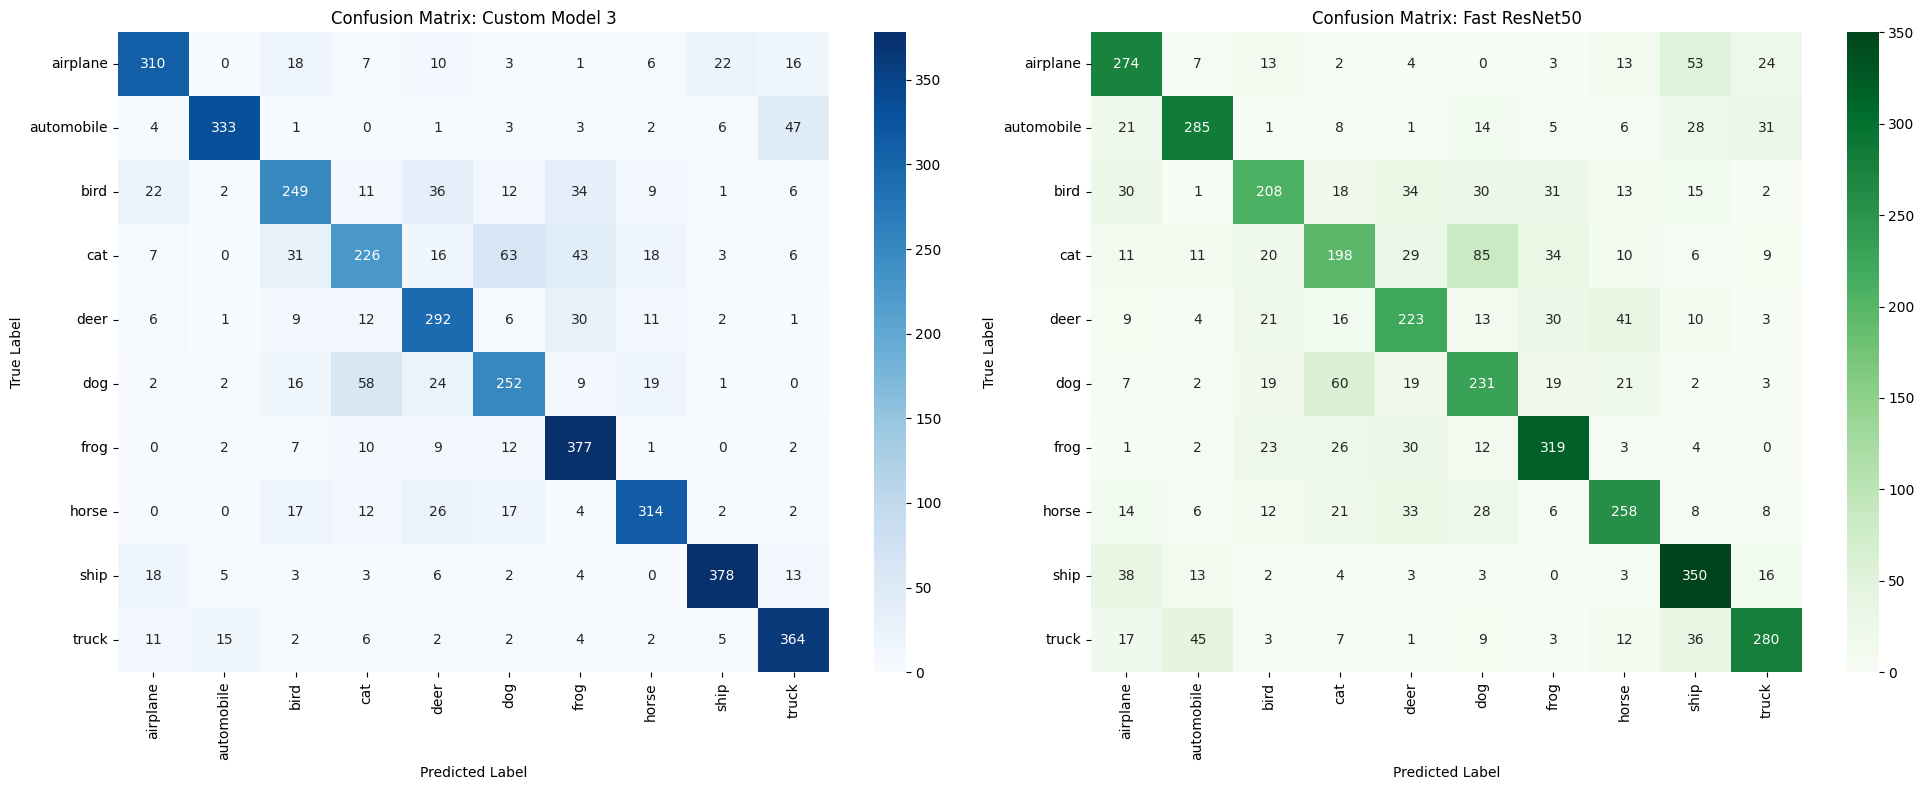

In [ ]:
# Calculate confusion matrices
cm_custom = confusion_matrix(y_true, y_pred_custom)
cm_resnet = confusion_matrix(y_true, y_pred_resnet)

# Plot side-by-side matrices
plt.figure(figsize=(20, 8))

# Custom Model Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Custom Model 3')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# ResNet50 Matrix
plt.subplot(1, 2, 2)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Fast ResNet50')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()